# Clasificador de Videojuegos con CNN



In [3]:
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator


base_dir = 'videogames-cnn-dataset'
train_dir = os.path.join(base_dir,'train')
test_dir = os.path.join(base_dir, 'test')

train_datagen = ImageDataGenerator(
							rescale = 1./255,
							rotation_range = 10,
							width_shift_range = 0.2,
						#	height_shift_range = 0.2,
						#	shear_range = 0.3,
							zoom_range = 0.3,
							horizontal_flip = True)

ModuleNotFoundError: No module named 'matplotlib'

Found 115496 images belonging to 21 classes.


<Figure size 640x480 with 0 Axes>

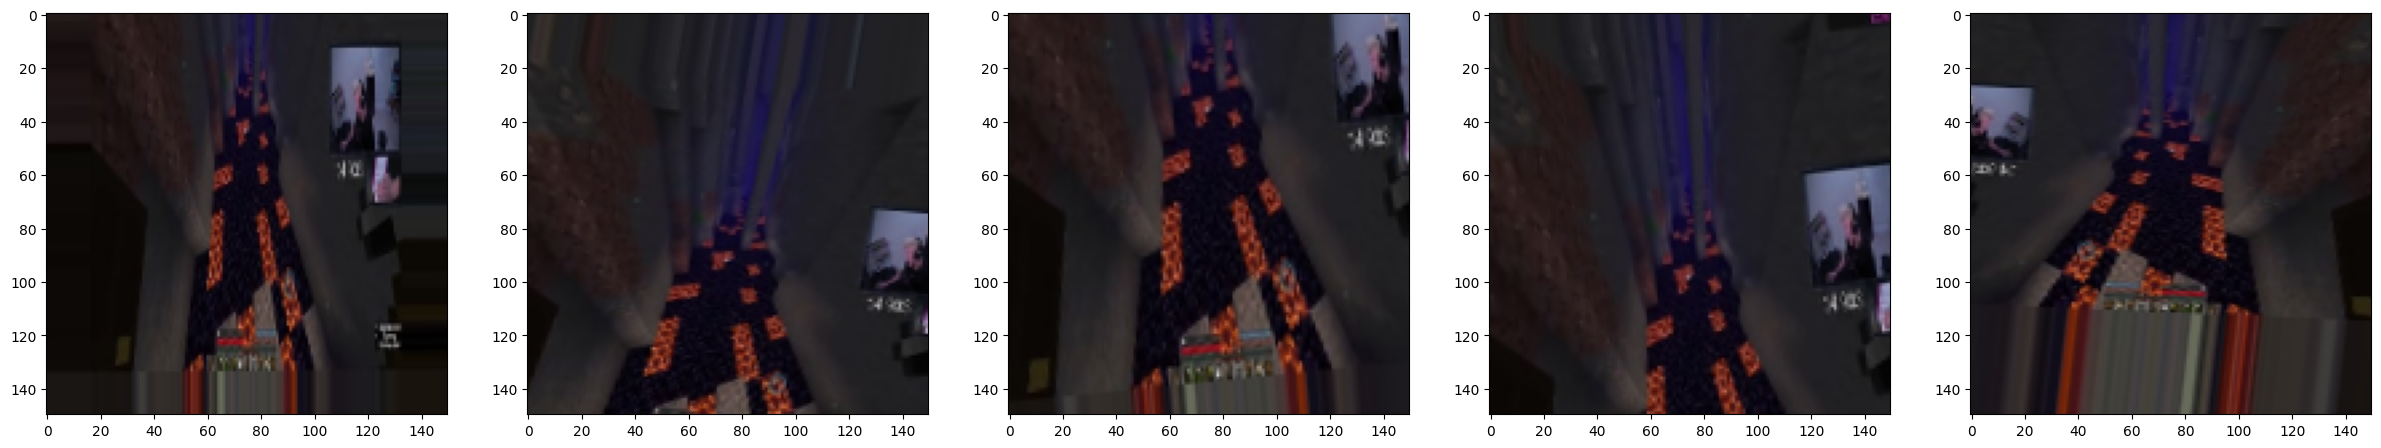

In [ ]:
train_generator = train_datagen.flow_from_directory(
							train_dir,
							target_size = (150, 150),
							batch_size = 256,
							class_mode ='binary',
							)


plt.figure()
#subplot(r,c) provide the no. of rows and columns
f, axarr = plt.subplots(1, 5, figsize=(30, 8))

for i in range(5) :
  axarr[i].imshow(train_generator[0][0][0])

Found 115496 images belonging to 21 classes.
(256, 150, 150, 3)
[[1. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 1. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 1. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]]


<Figure size 640x480 with 0 Axes>

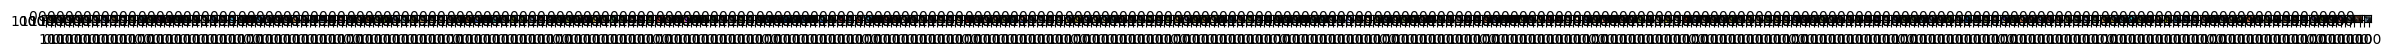

In [ ]:
train_generator = train_datagen.flow_from_directory(
							train_dir,
							target_size = (150, 150),
							batch_size = 256,
							class_mode ='categorical',
							)


images , labels = train_generator[0]

print(images.shape)
print(labels)


plt.figure()
#subplot(r,c) provide the no. of rows and columns
f, axarr = plt.subplots(1, images.shape[0], figsize=(30, 4))

for i in range(images.shape[0]) :
  axarr[i].imshow(images[i])

In [ ]:
path = "videogames-cnn-dataset"

train_generator = train_datagen.flow_from_directory(
							train_dir,
							target_size = (150, 150),
							batch_size = 256,
							class_mode ='categorical',
							save_to_dir= path + '/augmented',
							save_prefix='aug',
							save_format='png'
							)

Found 115496 images belonging to 21 classes.


In [ ]:
from tensorflow.keras import optimizers
from tensorflow.keras import models
from tensorflow.keras import layers

model = models.Sequential()
model.add(layers.Conv2D(10, (3, 3), activation="relu", input_shape = (150,150,3)))
model.add(layers.Flatten())
model.add(layers.Dense(256,activation='relu'))
model.add(layers.Dense(21,activation='sigmoid'))

model.summary()

model.compile(loss='binary_crossentropy',
						optimizer=optimizers.RMSprop(learning_rate=2e-5),
						metrics=['acc'])


C:\Users\YEPLO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 219040)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    56,074,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 21)             │         5,397 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,080,173 (213.93 MB)

 Trainable params: 56,080,173 (213.93 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import tensorflow as tf

print(tf.__version__)

# Listar las GPUs disponibles
gpus = tf.config.list_physical_devices('GPU')
print("GPUs disponibles:", len(gpus))

if gpus:
    for gpu in gpus:
        print(f"Nombre del dispositivo: {gpu}")
else:
    print("No se detectó ninguna GPU. Se usará la CPU.")

2.21.0
GPUs disponibles: 0
No se detectó ninguna GPU. Se usará la CPU.


In [4]:
import tensorflow as tf

# Esto debe devolver una lista con tu GPU
print("Dispositivos detectados:", tf.config.list_physical_devices())

# Esto confirma que TF puede usar la GPU para cálculos
print("¿TensorFlow puede usar la GPU?:", tf.test.is_built_with_cuda())


ModuleNotFoundError: No module named 'tensorflow'

In [ ]:
'''
history = model.fit(
						train_generator,
						epochs = 4)


acc = history.history['acc']
loss = history.history['loss']

epochs = range(1, len(acc)+1)

plt.plot(epochs,acc,'bo',label='train accuracy')
plt.title('train acc')
plt.legend()

plt.figure()

plt.plot(epochs,loss, 'bo', label ='training loss')
plt.title('train loss')
plt.legend()

plt.show()
'''

"\nhistory = model.fit(\n\t\t\t\t\t\ttrain_generator,\n\t\t\t\t\t\tepochs = 4)\n\n\nacc = history.history['acc']\nloss = history.history['loss']\n\nepochs = range(1, len(acc)+1)\n\nplt.plot(epochs,acc,'bo',label='train accuracy')\nplt.title('train acc')\nplt.legend()\n\nplt.figure()\n\nplt.plot(epochs,loss, 'bo', label ='training loss')\nplt.title('train loss')\nplt.legend()\n\nplt.show()\n"